TASK 1


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


TASK 2

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(28*28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 28*28)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


TASK 3


In [4]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD


TASK 4


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
train_losses = []


# TRAINIG LOOP

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for data, _ in train_loader:
        data = data.view(-1, 28*28).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")


Epoch [1/20] Loss: 165.8523
Epoch [2/20] Loss: 121.6505
Epoch [3/20] Loss: 114.3328
Epoch [4/20] Loss: 111.3254
Epoch [5/20] Loss: 109.6122
Epoch [6/20] Loss: 108.4906
Epoch [7/20] Loss: 107.6182
Epoch [8/20] Loss: 106.9788
Epoch [9/20] Loss: 106.4574
Epoch [10/20] Loss: 106.0943
Epoch [11/20] Loss: 105.7435
Epoch [12/20] Loss: 105.4664
Epoch [13/20] Loss: 105.1614
Epoch [14/20] Loss: 104.9546
Epoch [15/20] Loss: 104.7370
Epoch [16/20] Loss: 104.5545
Epoch [17/20] Loss: 104.3544
Epoch [18/20] Loss: 104.2035
Epoch [19/20] Loss: 104.0831
Epoch [20/20] Loss: 103.9308


TASK 5


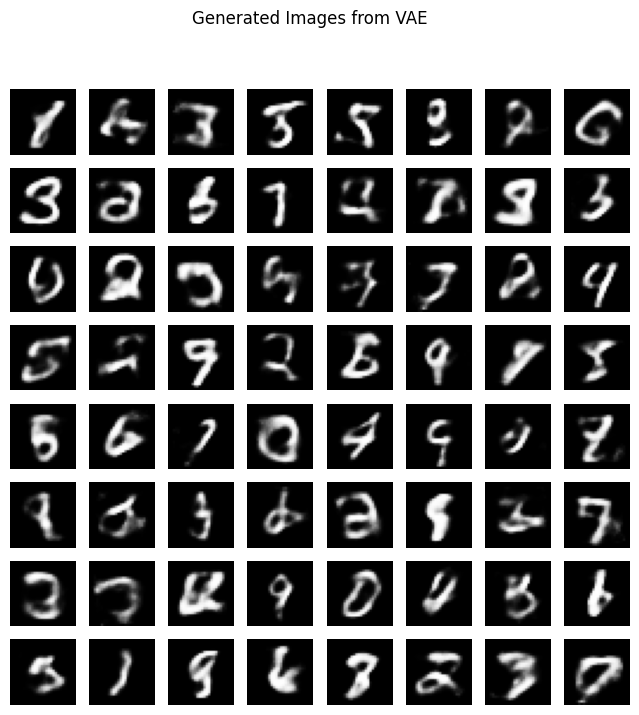

In [6]:
model.eval()

with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    samples = model.decode(z).cpu()


# VISUALISATION

plt.figure(figsize=(8,8))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(samples[i].view(28,28), cmap='gray')
    plt.axis('off')
plt.suptitle("Generated Images from VAE")
plt.show()


RECONSTRUCTED IMAGE

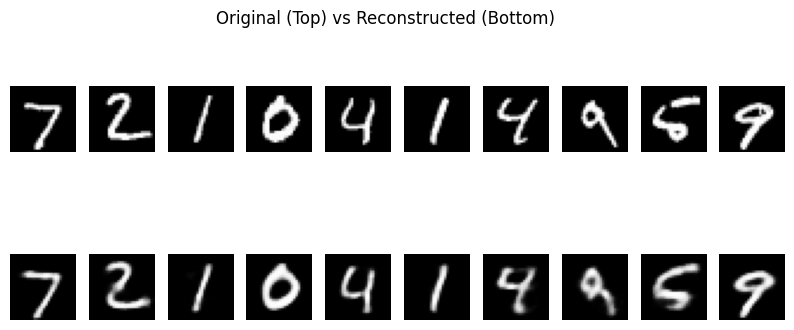

In [7]:
data, _ = next(iter(test_loader))
data = data.view(-1, 28*28).to(device)

with torch.no_grad():
    recon, _, _ = model(data)

plt.figure(figsize=(10,4))
for i in range(10):
    # original
    plt.subplot(2,10,i+1)
    plt.imshow(data[i].cpu().view(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(recon[i].cpu().view(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
plt.show()


TASK 6

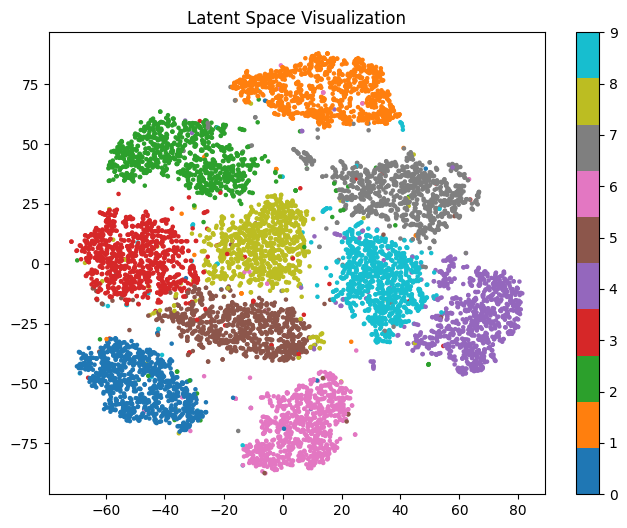

In [8]:
from sklearn.manifold import TSNE

model.eval()
latents = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.view(-1, 28*28).to(device)
        mu, _ = model.encode(data)
        latents.append(mu.cpu())
        labels.append(target)

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

tsne = TSNE(n_components=2)
latent_2d = tsne.fit_transform(latents)

plt.figure(figsize=(8,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("Latent Space Visualization")
plt.show()
